In [1]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

In [21]:
num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails: ", [heads, tails])

heads, tails:  [50, 50]


In [22]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(100, fair_probs).sample()

tensor([53., 47.])

In [23]:
Multinomial(100, fair_probs).sample() / 100

tensor([0.5200, 0.4800])

In [24]:
counts = Multinomial(10000, fair_probs).sample()
counts / 10000

tensor([0.4990, 0.5010])

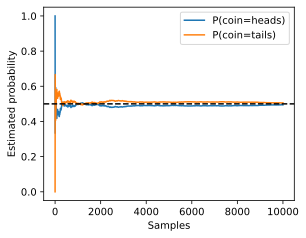

In [28]:
counts = Multinomial(1, fair_probs).sample((10000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label=("P(coin=heads)"))
d2l.plt.plot(estimates[:, 1], label=("P(coin=tails)"))
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Samples')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend()

Probability Theory

- a probability function maps events onto real values ${P: \mathcal{A} \subseteq \mathcal{S} \rightarrow [0,1]}$
- in a given sample space $S$, it has the following 3 properties

1. the probability of any event $A$ is a nonnegative real number
2. the probability of the entire sample space is $1$
3. for any countable sequence of events that are mutually exclusive, the probability that any of them happens is equal to the sum of their individual probabilities

